# Starting from ICON grids

In [39]:
import weather_model_graphs as wmg
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np

In [3]:
url = "https://swift.dkrz.de/v1/dkrz_948e7d4bbfbb445fbff5315fc433e36a/grids/EUREC4A_PR1250m_DOM01.zarr"
ds = xr.open_zarr(url, consolidated=True)
ds

<xarray.Dataset> Size: 3GB
Dimensions:                        (nc: 2, edge: 6795976, vertex: 2267417,
                                    cell: 4528560, ne: 6, nv: 3, no: 4,
                                    max_chdom: 1, cell_grf: 14, edge_grf: 24,
                                    vert_grf: 13)
Coordinates:
    elat                           (edge) float64 54MB ...
    elon                           (edge) float64 54MB ...
    vlat                           (vertex) float64 18MB ...
    vlon                           (vertex) float64 18MB ...
    clat                           (cell) float64 36MB ...
    clon                           (cell) float64 36MB ...
Dimensions without coordinates: nc, edge, vertex, cell, ne, nv, no, max_chdom,
                                cell_grf, edge_grf, vert_grf
Data variables: (12/51)
    adjacent_cell_of_edge          (nc, edge) int32 54MB ...
    cartesian_x_vertices           (vertex) float64 18MB ...
    cartesian_y_vertices           (vertex) float64 18MB ...
    cartesian_z_vertices           (vertex) float64 18MB ...
    cell_area                      (cell) float64 36MB ...
    cell_area_p                    (cell) float64 36MB ...
    ...                             ...
    vertex_of_cell                 (nv, cell) int32 54MB ...
    vertices_of_vertex             (ne, vertex) int32 54MB ...
    vlat_vertices                  (vertex, ne) float64 109MB ...
    vlon_vertices                  (vertex, ne) float64 109MB ...
    zonal_normal_dual_edge         (edge) float64 54MB ...
    zonal_normal_primal_edge       (edge) float64 54MB ...
Attributes: (12/18)
    ICON_grid_file_uri:   
    centre:               78
    crs_id:               urn:ogc:def:cs:EPSG:6.0:6422
    crs_name:             Spherical 2D Coordinate System
    ellipsoid_name:       Sphere
    global_grid:          0
    ...                   ...
    semi_major_axis:      6371229.0
    source:               svn://xceh.dwd.de/for0adm/SVN_icontools/tags/iconto...
    subcentre:            255
    title:                ICON grid description
    uuidOfHGrid:          6b59890b-99f3-939b-e76a-0a3ad2e43140
    uuidOfParHGrid:       39f9d5e2-322c-11e6-beee-d15f30d0a215

In [21]:
g = wmg.load.graph_from_icon_grid(ds.isel(cell=slice(None, None)))

In [43]:
# collect lon and lat values for all nodes
lons = [g.nodes[node]["pos"][0] for node in g.nodes]
lats = [g.nodes[node]["pos"][1] for node in g.nodes]

# compute percentiles to identify the range of lon and lat values, which can help in setting plot limits
print(len(g.nodes))
percentiles = [0.5, 99.5]
print(f"lon {percentiles}th percentiles:", np.percentile(lons, percentiles))
print(f"lat {percentiles}th percentiles:", np.percentile(lats, percentiles))

4528560
lon [0.5, 99.5]th percentiles: [-1.05042906 -0.78659272]
lat [0.5, 99.5]th percentiles: [0.13159129 0.2960053 ]


In [45]:
lon_max = -1.05
lat_max = 0.132
g_subset = wmg.filter_graph(
    g, **{"node__pos[0]__lt": lon_max, "node__pos[1]__lt": lat_max}
)
len(g_subset.nodes)

225

Text(0.5, 1.0, 'ICON grid subset')

Matplotlib is building the font cache; this may take a moment.


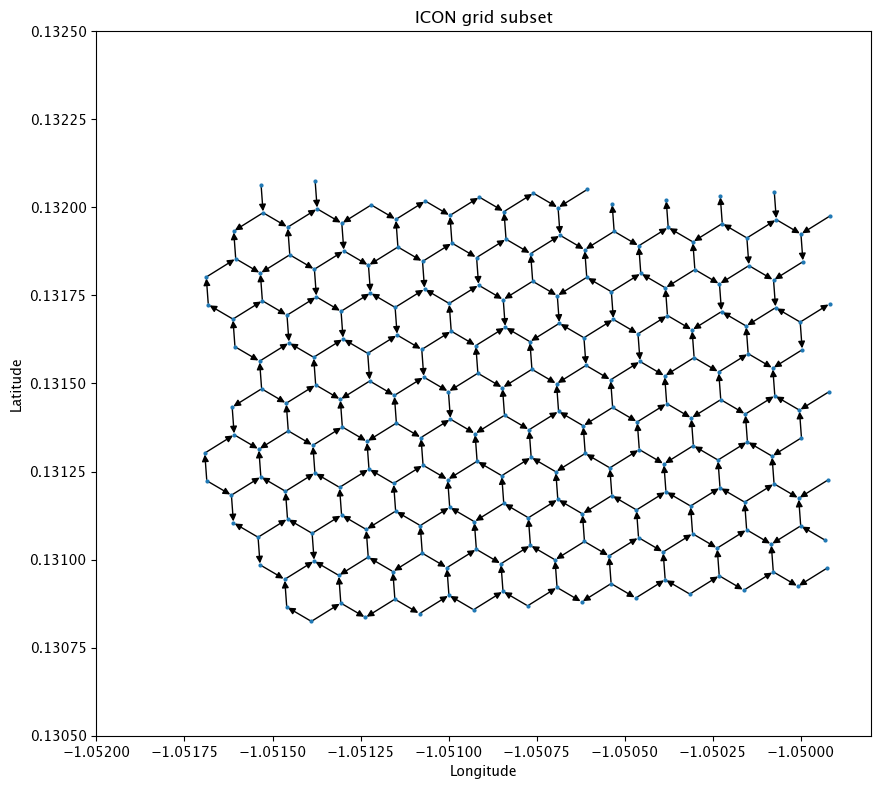

In [62]:
fig, ax = plt.subplots(figsize=(10, 10))
# use connection style that are just stright lines between nodes, which is more appropriate for a grid layout
wmg.visualise.nx_draw_with_pos_and_attr(
    g_subset, node_size=4, ax=ax, connectionstyle="arc3,rad=0"
)
ax.set_xlim(-1.052, -1.0498)
ax.set_ylim(0.1305, 0.1325)
ax.set_aspect("equal")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("ICON grid subset")